In [ ]:
# Provides CIFAR-10 Dataset and Image Classifier (fully-connected MLP) and helpers
# To be used as a black-boxed predictor

import torch
import torchvision
from torchvision.transforms import v2
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split


class MLP(nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=128, output_dim=10):
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = F.relu(self.hidden(x))
        x = self.out(x)
        return x

def load_data(batch_size=64):
    transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    full_trainset = torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=transform,
    )

    testset = torchvision.datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=transform,
    )

    train_size = 45000
    val_size = 5000

    trainset, calset = random_split(
        full_trainset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    trainloader = DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
    )

    calloader = DataLoader(
        calset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
    )

    testloader = DataLoader(
        testset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
    )

    return trainloader, calloader, testloader

# Train and Eval for one epoch

def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(loader.dataset)


In [ ]:
import math
import torch
from torch import nn
import torch.nn.functional as F

# helpers

def score(x, y):
    probs = F.softmax(x, dim=1)
    true_probs = probs[torch.arange(len(y)), y]
    return 1 - true_probs

#c calibrate to find quantiles, then make predictive sets

@torch.no_grad()
def calibrate(model, loader, alpha, device):
    scores = []
    model.eval()
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        logits = model(inputs)
        scores.append(score(logits, targets))
    scores = torch.cat(scores)
    n = scores.size(0)
    # ⌈(1 − α)(n + 1)⌉/n
    quantile = math.ceil((1 - alpha) * (n + 1)) / n
    quantile = min(quantile, 1.0) #clamp to 1.0 in case values are greater than 1
    qhat = torch.quantile(scores, quantile)
    return qhat

@torch.no_grad()
def make_sets(model, x, qhat):
    model.eval()

    logits = model(x)

    csets = []

    for i in range(x.size(0)):
        cset = []

        for label in range(10):
            y = torch.tensor([label], device=x.device)
            s = score(logits[i:i+1], y)
            if s.item() <= qhat:
                cset.append(label)
        csets.append(cset)
    return csets

In [ ]:

import torch
from torch import nn
import torch.nn.functional as F

class CoveragePolicy(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1 + num_classes, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        nn.init.zeros_(self.net[-1].weight)
        nn.init.constant_(self.net[-1].bias, 2.1972246)

    def forward(self, cal_sum, test_summary):
        if cal_sum.dim() == 0:
            cal_sum = cal_sum.view(1, 1).expand(test_summary.size(0), 1)
        elif cal_sum.dim() == 1:
            cal_sum = cal_sum.view(-1, 1)

        cal_sum = torch.log1p(cal_sum)
        test_summary = torch.log1p(test_summary)

        x = torch.cat([cal_sum, test_summary], dim=1)

        raw = self.net(x).squeeze(-1)

        eps = 1e-4
        return eps + (1 - 2 * eps) * torch.sigmoid(raw)

def policy_loss(smooth_sizes, alphas, lambda_reg):
    return (smooth_sizes + lambda_reg * alphas).mean()

# gets test summary statistic for each example

def candidate_scores(logits):
    labels = torch.arange(logits.size(1), device=logits.device)
    repeated_logits = logits.expand(logits.size(1), -1)
    return score(repeated_logits, labels).view(1, -1)

def smooth_size(logits, total_score, n, alpha, k=10.0):
    labels = torch.arange(logits.size(1), device=logits.device)
    repeated_logits = logits.expand(logits.size(1), -1)

    test_scores = score(repeated_logits, labels)
    e_values = ((n + 1) * test_scores) / (total_score + test_scores)

    return torch.sigmoid(k * ((1 / alpha) - e_values)).sum()

def train_policy(model, calloader, device, lambda_reg=1.0, epochs=3, lr=1e-3, k=10.0):
    model.eval()

    all_logits = []
    all_labels = []

    with torch.no_grad():
        for inputs, targets in calloader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            logits = model(inputs)

            all_logits.append(logits)
            all_labels.append(targets)

    X_cal = torch.cat(all_logits, dim=0)
    Y_cal = torch.cat(all_labels, dim=0)

    cal_scores = score(X_cal, Y_cal)
    full_total_score = cal_scores.sum()
    n = cal_scores.size(0)

    policy = CoveragePolicy(num_classes=X_cal.size(1)).to(device)
    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)

    for epoch in range(epochs):
        smooth_sizes = []
        alphas = []

        for i in range(n):
            x_i = X_cal[i:i+1]

            loo_total_score = full_total_score - cal_scores[i]
            loo_n = n - 1

            test_summary = candidate_scores(x_i)
            alpha_i = policy(loo_total_score, test_summary).squeeze()

            size_i = smooth_size(
                logits=x_i,
                total_score=loo_total_score,
                n=loo_n,
                alpha=alpha_i,
                k=k
            )

            smooth_sizes.append(size_i)
            alphas.append(alpha_i)

        smooth_sizes = torch.stack(smooth_sizes)
        alphas = torch.stack(alphas)

        loss = policy_loss(smooth_sizes, alphas, lambda_reg)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"policy epoch {epoch+1}: loss={loss.item():.4f}")

    return policy

@torch.no_grad()
def loo_policy_size(model, policy, calloader, device):
    model.eval()
    policy.eval()

    all_logits = []
    all_labels = []

    for inputs, targets in calloader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        logits = model(inputs)

        all_logits.append(logits)
        all_labels.append(targets)

    X_cal = torch.cat(all_logits, dim=0)
    Y_cal = torch.cat(all_labels, dim=0)

    cal_scores = score(X_cal, Y_cal)
    full_total_score = cal_scores.sum()
    n = cal_scores.size(0)

    sizes = []

    for i in range(n):
        x_i = X_cal[i:i+1]
        loo_total_score = full_total_score - cal_scores[i]
        loo_n = n - 1

        alpha_i = policy(loo_total_score, candidate_scores(x_i)).item()

        cset = []

        for label in range(X_cal.size(1)):
            y = torch.tensor([label], device=device)

            e_value = soft_rank(
                loo_total_score,
                loo_n,
                x_i,
                y,
            )

            if e_value.item() <= 1 / alpha_i:
                cset.append(label)

        sizes.append(len(cset))

    return sum(sizes) / len(sizes)

def select_lambda(model,calloader,device,target_size,tolerance=0.1,initial_lambda=1.0,max_steps=8,):
    lam_low = initial_lambda
    lam_high = initial_lambda

    # train/evaluate helper
    def fit_and_measure(lam):
        policy = train_policy(
            model=model,
            calloader=calloader,
            device=device,
            lambda_reg=lam,
            epochs=3,
            lr=1e-3,
        )
        size = loo_policy_size(model, policy, calloader, device)
        return policy, size

    # start at initial lambda
    policy, size = fit_and_measure(initial_lambda)
    print(f"lambda={initial_lambda:.4f}, loo_size={size:.4f}")

    if abs(size - target_size) <= tolerance:
        return initial_lambda, policy, size

    # bracket target
    if size < target_size:
        # sets too small, increase lambda
        lam_low = initial_lambda

        for _ in range(max_steps):
            lam_high *= 2
            policy, size = fit_and_measure(lam_high)
            print(f"lambda={lam_high:.4f}, loo_size={size:.4f}")

            if size >= target_size:
                break
        else:
            return lam_high, policy, size

    else:
        # sets too large, decrease lambda
        lam_high = initial_lambda

        for _ in range(max_steps):
            lam_low /= 2
            policy, size = fit_and_measure(lam_low)
            print(f"lambda={lam_low:.4f}, loo_size={size:.4f}")

            if size <= target_size:
                break
        else:
            return lam_low, policy, size

    # bisection
    best_lam = None
    best_policy = None
    best_size = None
    best_err = float("inf")

    for _ in range(max_steps):
        lam_mid = 0.5 * (lam_low + lam_high)

        policy, size = fit_and_measure(lam_mid)
        err = abs(size - target_size)

        print(f"lambda={lam_mid:.4f}, loo_size={size:.4f}")

        if err < best_err:
            best_err = err
            best_lam = lam_mid
            best_policy = policy
            best_size = size

        if err <= tolerance:
            break

        if size < target_size:
            lam_low = lam_mid
        else:
            lam_high = lam_mid

    return best_lam, best_policy, best_size


# x are logits
def score(x, y):
    log_probs = F.log_softmax(x, dim=1)
    batch_indices = torch.arange(len(y), device=y.device)
    return -log_probs[batch_indices, y]

def soft_rank(total_score, n, x_test, y_test):
    test_score = score(x_test, y_test)
    return ((n + 1) * test_score) / (total_score + test_score)

@torch.no_grad()
def make_e_sets(model, x, alpha, total_score, n, policy=None, return_alphas=False):
    model.eval()

    if policy is not None:
        policy.eval()

    logits = model(x)
    csets = []
    alphas = []

    if not torch.is_tensor(total_score):
        total_score = torch.tensor(total_score, device=x.device, dtype=logits.dtype)
    else:
        total_score = total_score.to(device=x.device, dtype=logits.dtype)

    for i in range(x.size(0)):
        x_i = logits[i:i+1]

        if policy is None:
            alpha_i = alpha
        else:
            alpha_i = policy(total_score, candidate_scores(x_i)).item()

        alphas.append(alpha_i)

        cset = []

        for label in range(logits.size(1)):
            y = torch.tensor([label], device=x.device)

            e_value = soft_rank(total_score,n,x_i,y)

            if e_value.item() < (1 / alpha_i):
                cset.append(label)

        csets.append(cset)

    if return_alphas:
        return csets, alphas

    return csets

# calibration score sum does not change, this function improves efficiency
# and lets us cache the score for later

@torch.no_grad()
def get_cal_total_score(model, calloader, device):
    model.eval()
    total_score = 0.0
    n = 0

    for inputs, targets in calloader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        logits = model(inputs)
        batch_scores = score(logits, targets)

        total_score += batch_scores.sum()
        n += batch_scores.size(0)

    return total_score, n

@torch.no_grad()
def loo_average_size(model, calloader, alpha, device, num_classes=10):
    model.eval()

    # get all calibration examples and scores

    all_logits = []
    all_labels = []

    for inputs, targets in calloader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        logits = model(inputs)

        all_logits.append(logits)
        all_labels.append(targets)

    X_cal = torch.cat(all_logits, dim=0)
    Y_cal = torch.cat(all_labels, dim=0)

    cal_scores = score(X_cal, Y_cal)
    full_total_score = cal_scores.sum()
    n = cal_scores.size(0)

    sizes = []
    # LOO
    for i in range(n):
        x_test = X_cal[i:i+1]

        loo_total_score = full_total_score - cal_scores[i]

        loo_n = n - 1

        cset = []

        for label in range(num_classes):
            y_test = torch.tensor([label], device=device)

            e_value = soft_rank(
                loo_total_score,
                loo_n,
                x_test,
                y_test
            )

            if e_value.item() <= (1 / alpha):
                cset.append(label)

        sizes.append(len(cset))

    return sum(sizes) / len(sizes)

In [ ]:
def verify():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"device: {device}")

    trainloader, calloader, testloader = load_data()

    model = MLP().to(device)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.01,
        momentum=0.9,
    )

    criterion = nn.CrossEntropyLoss()

    print("\nTraining base classifier...")

    for epoch in range(5):
        model.train()
        total_loss = 0.0
        total = 0

        for inputs, targets in trainloader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            logits = model(inputs)
            loss = criterion(logits, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            total += inputs.size(0)

        train_loss = total_loss / total

        model.eval()
        test_loss = 0.0
        test_total = 0
        correct = 0

        with torch.no_grad():
            for inputs, targets in testloader:
                inputs = inputs.to(device)
                targets = targets.to(device)

                logits = model(inputs)
                loss = criterion(logits, targets)

                test_loss += loss.item() * inputs.size(0)
                test_total += inputs.size(0)

                preds = logits.argmax(dim=1)
                correct += (preds == targets).sum().item()

        test_loss = test_loss / test_total
        test_acc = correct / test_total

        print(
            f"epoch {epoch + 1}: "
            f"train_loss={train_loss:.4f}, "
            f"test_loss={test_loss:.4f}, "
            f"test_acc={test_acc:.4f}"
        )

    total_score, n = get_cal_total_score(
        model=model,
        calloader=calloader,
        device=device,
    )

    print(f"\nCalibration n={n}")
    print(f"Calibration total score={total_score.item():.4f}")

    lambdas = [0.001, 0.01, 0.1]

    for lambda_reg in lambdas:
        print("\n" + "=" * 60)
        print(f"λ = {lambda_reg}")

        policy = train_policy(
            model=model,
            calloader=calloader,
            device=device,
            lambda_reg=lambda_reg,
            epochs=20,
            lr=1e-3,
            k=1.0,
        )
        policy.eval()
        model.eval()

        all_alphas = []
        total = 0
        covered = 0
        total_set_size = 0

        with torch.no_grad():
            for inputs, targets in testloader:
                inputs = inputs.to(device)
                targets = targets.to(device)

                csets, alpha_tilde_test = make_e_sets(
                    model=model,
                    x=inputs,
                    alpha=None,
                    total_score=total_score,
                    n=n,
                    policy=policy,
                    return_alphas=True,
                )

                all_alphas.extend(alpha_tilde_test)

                for cset, y in zip(csets, targets):
                    total += 1
                    total_set_size += len(cset)

                    if y.item() in cset:
                        covered += 1

        alpha_tensor = torch.tensor(all_alphas)

        coverage = covered / total
        miscoverage = 1.0 - coverage
        avg_alpha = alpha_tensor.mean().item()
        avg_set_size = total_set_size / total

        print(f"alpha mean: {avg_alpha:.4f}")
        print(f"alpha std: {alpha_tensor.std().item():.4f}")
        print(f"alpha min/max: {alpha_tensor.min().item():.4f} / {alpha_tensor.max().item():.4f}")

        print(f"coverage: {coverage:.4f}")
        print(f"miscoverage: {miscoverage:.4f}")
        print(f"avg set size: {avg_set_size:.4f}")

        print(f"miscoverage / avg alpha: {miscoverage / avg_alpha:.4f}")

        quantiles = torch.quantile(
            alpha_tensor,
            torch.tensor([0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0])
        )

        print("alpha quantiles:")
        print(quantiles)

    print("\nVerification complete.")


device: cuda

Training base classifier...
epoch 1: train_loss=1.6783
epoch 2: train_loss=1.4865
epoch 3: train_loss=1.4014
epoch 4: train_loss=1.3433
epoch 5: train_loss=1.2875

Training adaptive coverage policy...
policy epoch 1: loss=2.4597
policy epoch 2: loss=2.4574
policy epoch 3: loss=2.4552
policy epoch 4: loss=2.4529
policy epoch 5: loss=2.4506
policy epoch 6: loss=2.4483
policy epoch 7: loss=2.4459
policy epoch 8: loss=2.4435
policy epoch 9: loss=2.4411
policy epoch 10: loss=2.4387
policy epoch 11: loss=2.4362
policy epoch 12: loss=2.4337
policy epoch 13: loss=2.4312
policy epoch 14: loss=2.4287
policy epoch 15: loss=2.4262
policy epoch 16: loss=2.4236
policy epoch 17: loss=2.4210
policy epoch 18: loss=2.4184
policy epoch 19: loss=2.4158
policy epoch 20: loss=2.4132
policy epoch 21: loss=2.4106
policy epoch 22: loss=2.4080
policy epoch 23: loss=2.4054
policy epoch 24: loss=2.4028
policy epoch 25: loss=2.4002
policy epoch 26: loss=2.3977
policy epoch 27: loss=2.3951
policy epoc

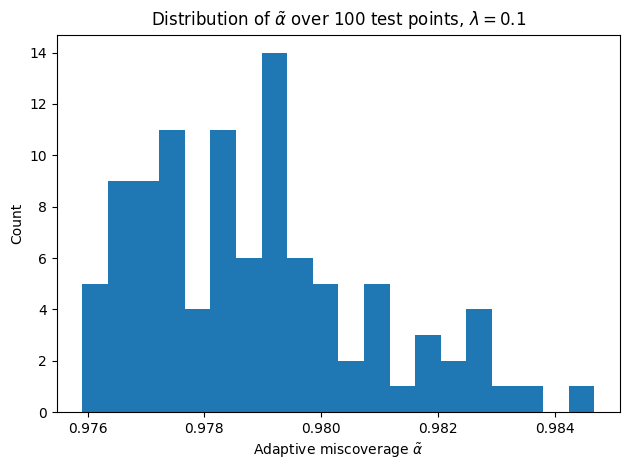

In [ ]:
def main():
    import random
    import numpy as np
    import matplotlib.pyplot as plt

    seed = 0
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"device: {device}")

    trainloader, calloader, testloader = load_data()

    model = MLP().to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    print("\nTraining base classifier...")
    for epoch in range(5):
        model.train()
        total_loss = 0.0
        total = 0

        for inputs, targets in trainloader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            logits = model(inputs)
            loss = criterion(logits, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            total += inputs.size(0)

        print(f"epoch {epoch + 1}: train_loss={total_loss / total:.4f}")

    total_score, n = get_cal_total_score(model, calloader, device)

    lambda_reg = 0.1

    print("\nTraining adaptive coverage policy...")
    policy = train_policy(
        model=model,
        calloader=calloader,
        device=device,
        lambda_reg=lambda_reg,
        epochs=50,
        lr=1e-3,
        k=1.0,
    )

    model.eval()
    policy.eval()

    all_inputs = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in testloader:
            all_inputs.append(inputs)
            all_targets.append(targets)

    X_test = torch.cat(all_inputs, dim=0)
    Y_test = torch.cat(all_targets, dim=0)

    idx = torch.randperm(X_test.size(0))[:100]
    X_sample = X_test[idx].to(device)
    Y_sample = Y_test[idx].to(device)

    alphas = []
    covered = 0
    total_set_size = 0

    with torch.no_grad():
        logits = model(X_sample)

        for i in range(X_sample.size(0)):
            x_i = logits[i:i+1]

            alpha_i = policy(
                total_score,
                candidate_scores(x_i)
            ).item()

            alphas.append(alpha_i)

            cset = []

            for label in range(logits.size(1)):
                y = torch.tensor([label], device=device)

                e_value = soft_rank(
                    total_score,
                    n,
                    x_i,
                    y,
                )

                if e_value.item() < (1 / alpha_i):
                    cset.append(label)

            total_set_size += len(cset)

            if Y_sample[i].item() in cset:
                covered += 1

    alphas = torch.tensor(alphas)

    print("\nFigure 2 check:")
    print(f"lambda: {lambda_reg}")
    print(f"alpha mean: {alphas.mean().item():.4f}")
    print(f"alpha std: {alphas.std().item():.4f}")
    print(f"alpha min/max: {alphas.min().item():.4f} / {alphas.max().item():.4f}")
    print(f"coverage on 100 sampled test points: {covered / 100:.4f}")
    print(f"avg set size on 100 sampled test points: {total_set_size / 100:.4f}")

    plt.figure()
    plt.hist(alphas.cpu().numpy(), bins=20)
    plt.xlabel(r"Adaptive miscoverage $\tilde{\alpha}$")
    plt.ylabel("Count")
    plt.title(rf"Distribution of $\tilde{{\alpha}}$ over 100 test points, $\lambda={lambda_reg}$")
    plt.tight_layout()
    plt.savefig("figure2_alpha_distribution.png", dpi=200)
    plt.show()

if __name__ == "__main__":
  main()